# Hồi quy tuyến tính (Linear Regression)

Cài đặt mô hình hồi quy tuyến tính với thư viện PyTorch

In [207]:
import torch
import numpy as np
import matplotlib.pyplot as plt
rng = np.random

In [208]:
# Parameters.
learning_rate = 0.01
training_steps = 1000
display_step = 50

In [209]:
# Xây dựng dữ liệu
X = np.array([3.3,4.4,5.5,6.71,6.93,4.168,9.779,6.182,7.59,2.167,
              7.042,10.791,5.313,7.997,5.654,9.27,3.1])
Y = np.array([1.7,2.76,2.09,3.19,1.694,1.573,3.366,2.596,2.53,1.221,
              2.827,3.465,1.65,2.904,2.42,2.94,1.3])

In [210]:
inputs = torch.from_numpy(X)
targets = torch.from_numpy(Y)

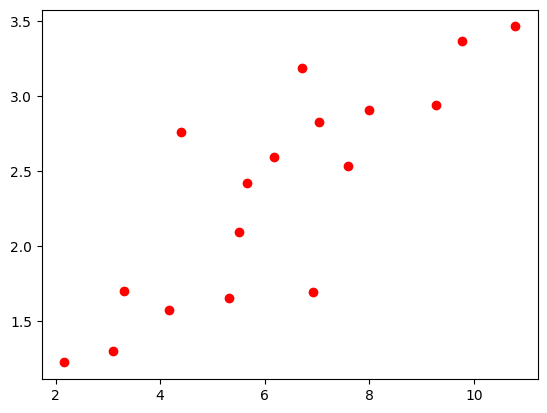

In [211]:
# Trực quan hóa dữ liệu
plt.plot(X, Y, 'ro', label='Original data')
plt.show()

In [212]:
# Xây dựng hàm hồi quy (Wx + b).
def model(x):
    return x * w + b

In [213]:
# Khởi tạo giá trị trọng số W và bias
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

In [214]:
# Xây dựng hàm mất mát (loss function)
# Đọc thêm về reduce_mean tại: https://docs.w3cub.com/tensorflow~python/tf/reduce_mean

# MSE loss
def mse(t1, t2):
    diff = t1 - t2
    return torch.sum(diff * diff) / diff.numel()

In [215]:
# Huấn luyện mô hình với training_steps đã được xác định từ trước
losses = []
for i in range(training_steps):
    preds = model(inputs)
    loss = mse(preds, targets)
    losses.append(loss)
    loss.backward()
    with torch.no_grad():
        w -= w.grad * learning_rate
        b -= b.grad * learning_rate
        w.grad.zero_()
        b.grad.zero_()

In [216]:
losses_np = []
for x in losses:
  y = x.detach().numpy()
  losses_np.append(y)

In [217]:
losses_np

[array(44.56768454),
 array(1.08709812),
 array(0.6773018),
 array(0.67096719),
 array(0.66842396),
 array(0.66592828),
 array(0.663445),
 array(0.66097379),
 array(0.65851457),
 array(0.65606726),
 array(0.65363183),
 array(0.65120824),
 array(0.64879638),
 array(0.64639621),
 array(0.64400769),
 array(0.64163077),
 array(0.63926536),
 array(0.63691141),
 array(0.63456888),
 array(0.63223773),
 array(0.62991787),
 array(0.62760924),
 array(0.62531181),
 array(0.62302554),
 array(0.62075033),
 array(0.61848619),
 array(0.61623304),
 array(0.61399076),
 array(0.61175939),
 array(0.60953882),
 array(0.60732902),
 array(0.60512993),
 array(0.60294153),
 array(0.60076373),
 array(0.59859648),
 array(0.59643974),
 array(0.59429347),
 array(0.59215759),
 array(0.5900321),
 array(0.58791693),
 array(0.58581202),
 array(0.58371729),
 array(0.58163269),
 array(0.57955825),
 array(0.57749383),
 array(0.57543943),
 array(0.57339503),
 array(0.57136052),
 array(0.56933589),
 array(0.56732108),
 ar

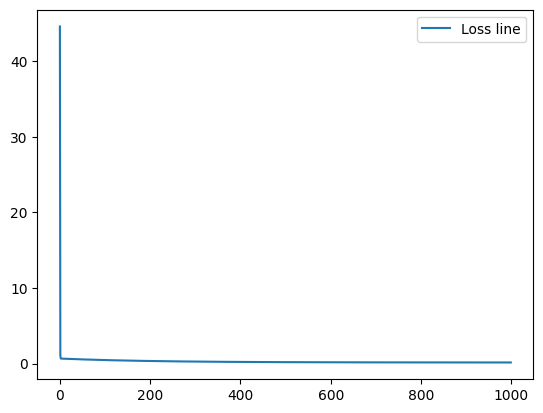

In [218]:
# Biểu đồ biểu diễn độ biến thiên của hàm mất mát qua các vòng lặp
plt.plot([i for i in range(len(losses))], losses_np, label='Loss line')
plt.legend()
plt.show()

In [219]:
import matplotlib.pyplot as plt

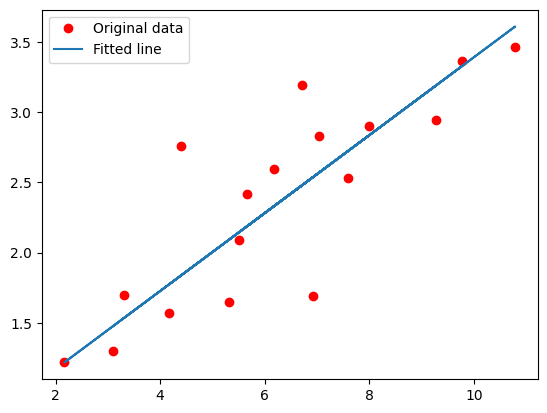

In [220]:
# Mô hình hóa sự tương quan giữa những điểm dữ liệu và phương trình tuyến tính
plt.plot(X, Y, 'ro', label='Original data')
plt.plot(X, (w * inputs + b).detach().numpy(), label='Fitted line')
plt.legend()
plt.show()